# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [18]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [19]:
file_1 = '/content/Churn_Modelling.csv'

In [20]:
df = pd.read_csv(file_1)

In [21]:
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [22]:
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

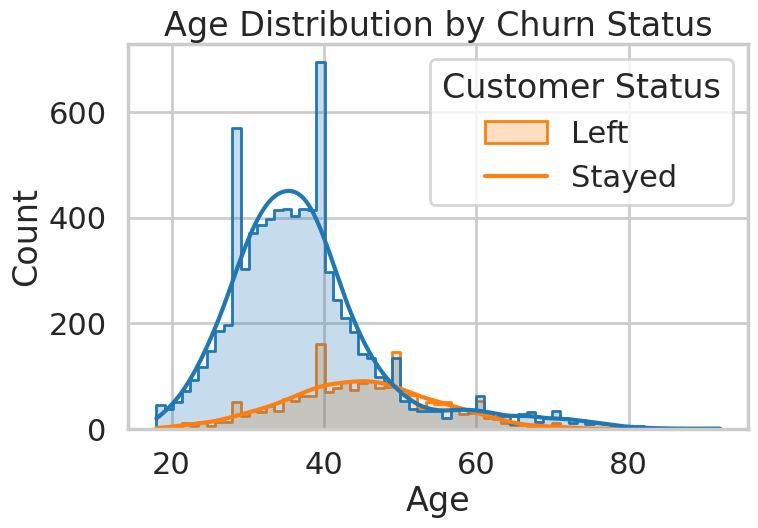

In [23]:
sns.histplot(data=df, x='Age', hue='Exited', kde=True, element='step')
plt.legend(title='Customer Status', labels=['Left', 'Stayed'])
plt.title('Age Distribution by Churn Status')
plt.show()

In [24]:
mean_age_0 = df_0['Age'].mean()
std_age_0 = df_0['Age'].std()
print(f'Stayed - Mean: {mean_age_0:.2f}, Std Dev: {std_age_0:.2f}')

Stayed - Mean: 37.41, Std Dev: 10.13


In [25]:
mean_age_1 = df_1['Age'].mean()
std_age_1 = df_1['Age'].std()
print(f'Left - Mean: {mean_age_1:.2f}, Std Dev: {std_age_1:.2f}')

Left - Mean: 44.84, Std Dev: 9.76


In [26]:
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f'T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}')

T-statistic: -29.7668, P-value: 0.0000


### Using Bootstrapping

In [27]:
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [28]:
diff_means = df_1['Age'].mean() - df_0['Age'].mean()
age_shifted_0 = df_0['Age'] - df_0['Age'].mean() + df['Age'].mean()
age_shifted_1 = df_1['Age'] - df_1['Age'].mean() + df['Age'].mean()

In [29]:
bs_replicates_0 = bs_choice(age_shifted_0, np.mean, 10000)
bs_replicates_1 = bs_choice(age_shifted_1, np.mean, 10000)
bs_diff_replicates = bs_replicates_1 - bs_replicates_0

In [30]:
p_value_bs = np.sum(bs_diff_replicates >= diff_means) / len(bs_diff_replicates)
print(f'Bootstrap P-value: {p_value_bs}')

Bootstrap P-value: 0.0


### Conclusion
**Reject the Null Hypothesis.** The p-value is extremely low (0.0), indicating a statistically significant difference in age between the two groups. Customers who left the bank are, on average, older (~44.8) than those who stayed (~37.4).

## Hypothesis 2: Credit Score

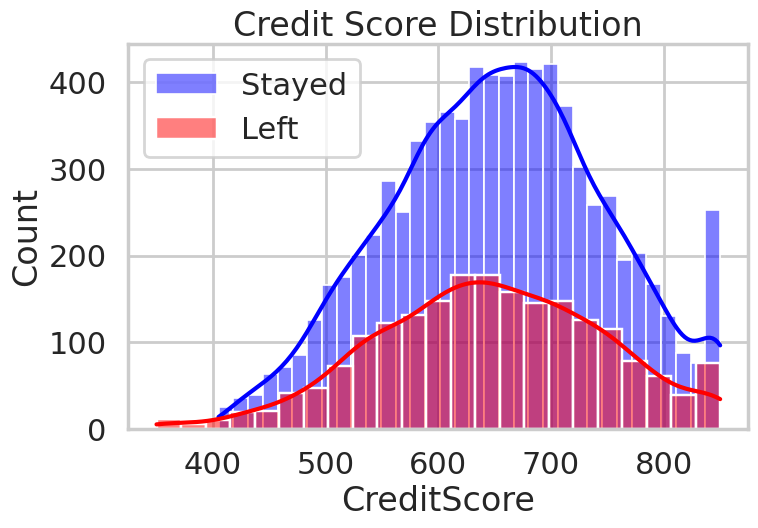

In [31]:
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['CreditScore'], color='red', label='Left', kde=True)
plt.legend()
plt.title('Credit Score Distribution')
plt.show()

In [32]:
t_stat_cs, p_val_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f'T-statistic: {t_stat_cs:.4f}, P-value: {p_val_cs:.4f}')

T-statistic: 2.7101, P-value: 0.0067


### Conclusion
**Reject the Null Hypothesis.** The p-value (0.0067) is less than 0.05. There is a statistically significant difference in credit scores, though the absolute difference may be small, it is mathematically relevant.

## Hypothesis 3: Balance

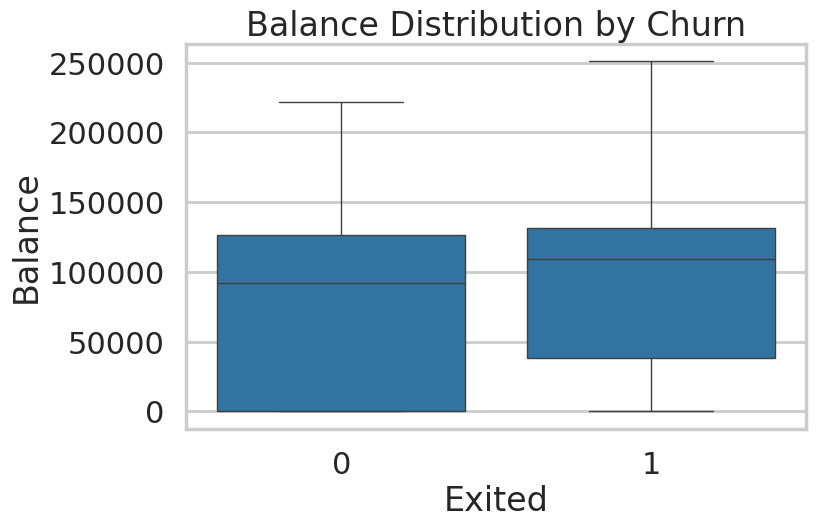

In [33]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance Distribution by Churn')
plt.show()

In [34]:
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print(f'T-statistic: {t_stat_bal:.4f}, P-value: {p_val_bal:.4f}')

T-statistic: -11.9362, P-value: 0.0000


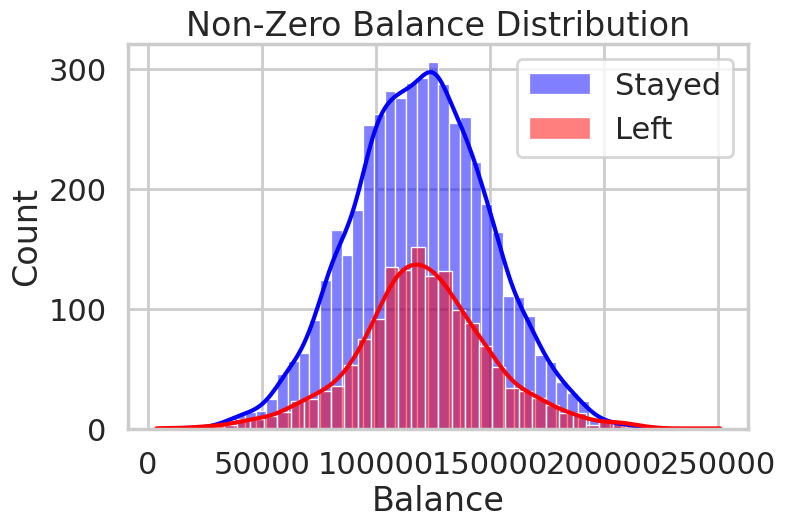

In [35]:
sns.histplot(df_0[df_0['Balance'] > 0]['Balance'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1[df_1['Balance'] > 0]['Balance'], color='red', label='Left', kde=True)
plt.legend()
plt.title('Non-Zero Balance Distribution')
plt.show()

In [36]:
t_stat_nz, p_val_nz = scipy.stats.ttest_ind(df_0[df_0['Balance'] > 0]['Balance'], df_1[df_1['Balance'] > 0]['Balance'])
print(f'T-statistic: {t_stat_nz:.4f}, P-value: {p_val_nz:.4f}')

T-statistic: -1.3748, P-value: 0.1692


### Conclusion
**Mixed Results.** When considering all customers, we **reject** the null hypothesis (p < 0.05). However, when excluding zero balances, the p-value (0.169) suggests we **fail to reject** the null hypothesis. This implies the act of having a zero balance is more significant than the specific amount held by non-zero balance customers.

## Hypothesis 4: Estimated Salary

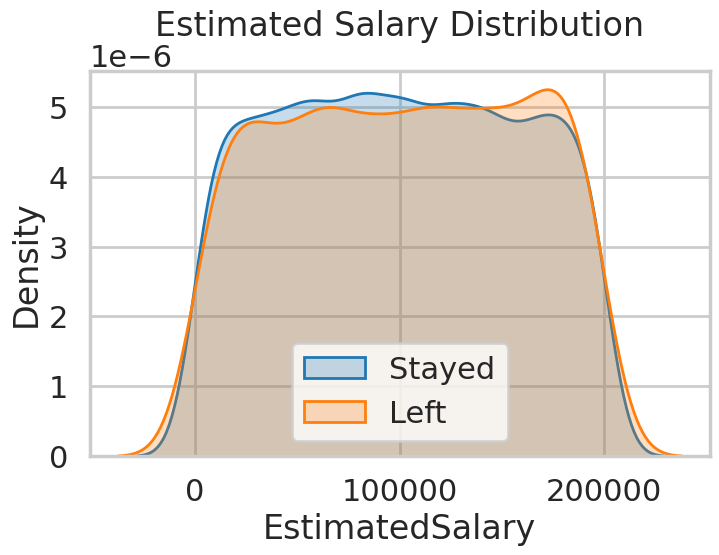

In [37]:
sns.kdeplot(df_0['EstimatedSalary'], label='Stayed', fill=True)
sns.kdeplot(df_1['EstimatedSalary'], label='Left', fill=True)
plt.legend()
plt.title('Estimated Salary Distribution')
plt.show()

In [38]:
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f'T-statistic: {t_stat_sal:.4f}, P-value: {p_val_sal:.4f}')

T-statistic: -1.2097, P-value: 0.2264


### Using Bootstrapping

In [39]:
diff_means_sal = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()
sal_shifted_0 = df_0['EstimatedSalary'] - df_0['EstimatedSalary'].mean() + df['EstimatedSalary'].mean()
sal_shifted_1 = df_1['EstimatedSalary'] - df_1['EstimatedSalary'].mean() + df['EstimatedSalary'].mean()

In [40]:
bs_sal_0 = bs_choice(sal_shifted_0, np.mean, 10000)
bs_sal_1 = bs_choice(sal_shifted_1, np.mean, 10000)
bs_diff_sal = bs_sal_1 - bs_sal_0

In [41]:
p_value_sal_bs = np.sum(np.abs(bs_diff_sal) >= np.abs(diff_means_sal)) / len(bs_diff_sal)
print(f'Bootstrap P-value (Salary): {p_value_sal_bs}')

Bootstrap P-value (Salary): 0.2388


### Conclusion
**Fail to reject the Null Hypothesis.** Both the t-test (p=0.226) and the bootstrap test (p=0.238) result in p-values much higher than 0.05. There is no evidence that the estimated salary differs significantly between customers who left and those who stayed.

## Final Conclusion
Based on the analysis, **Age** is the most helpful feature in predicting churn among the ones tested, showing the most dramatic difference in distribution and the lowest p-value. **Balance** (specifically whether it is zero or not) also plays a key role, while **Estimated Salary** appears to have no significant impact on a customer's decision to leave.